Tesla Sales & Price Data ML Pipeline
Project Objective

This project aims to analyze Tesla sales, production, and pricing data, build machine learning models for delivery prediction, and forecast future deliveries using time-series analysis.

Importing Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

Loading the Dataset

In [2]:
df=pd.read_csv('tesla.csv')

Dataset Overview

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
df.columns

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Data Quality Check

In [8]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

Date Feature Creation

In [10]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

In [11]:
df[["Year", "Month", "Date"]].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](

Categorical Data Exploration

In [13]:
df['Region'].unique()

array(['Europe', 'Asia', 'North America', 'Middle East'], dtype=object)

In [14]:
df['Model'].unique()

array(['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck'],
      dtype=object)

In [15]:
df['Source_Type'].unique()

array(['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)'],
      dtype=object)

In [16]:
df.to_csv("tesla_cleaned.csv", index=False)

Exploratory Data Analysis (EDA)
Description

Analyzing patterns, trends, and relationships in Tesla sales and production data.

Tesla Deliveries Over Years

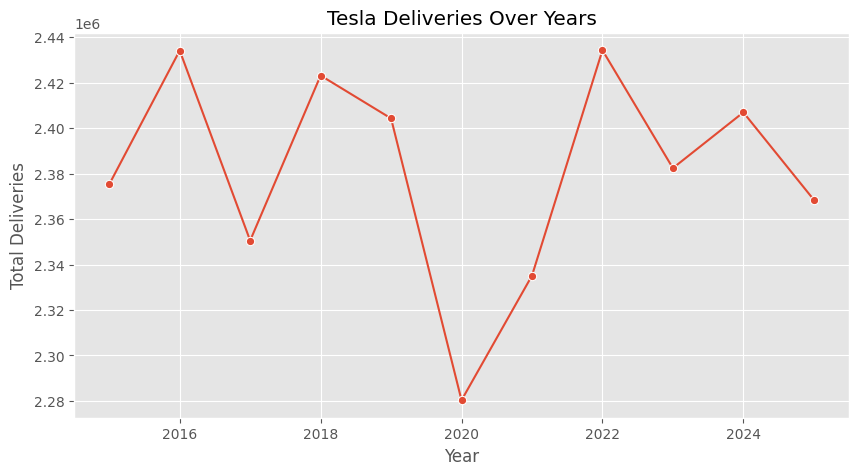

In [21]:
yearly_delivery = df.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly_delivery,
    x="Year",
    y="Estimated_Deliveries",
    marker="o"
)

plt.title("Tesla Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.show()

Model-wise Deliveries Analysis

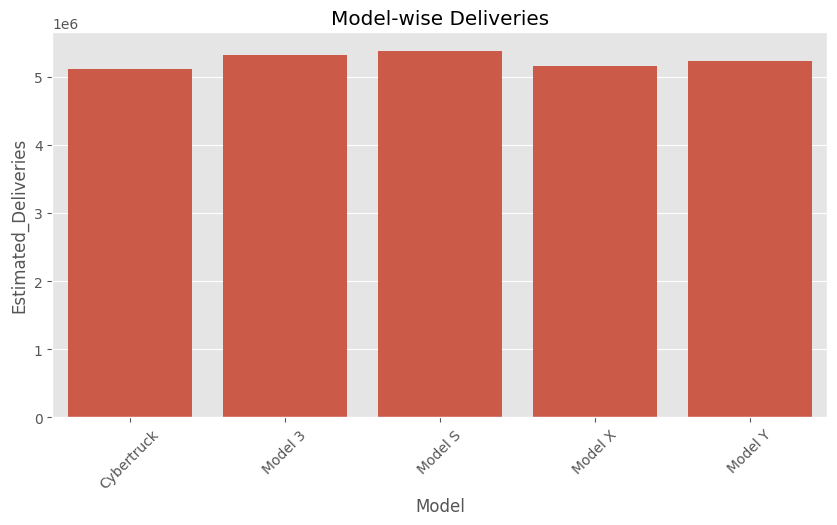

In [23]:
model_delivery = df.groupby("Model")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=model_delivery,
    x="Model",
    y="Estimated_Deliveries",
)

plt.title("Model-wise Deliveries")
plt.xticks(rotation=45)
plt.show()

Region-wise Deliveries Analysis

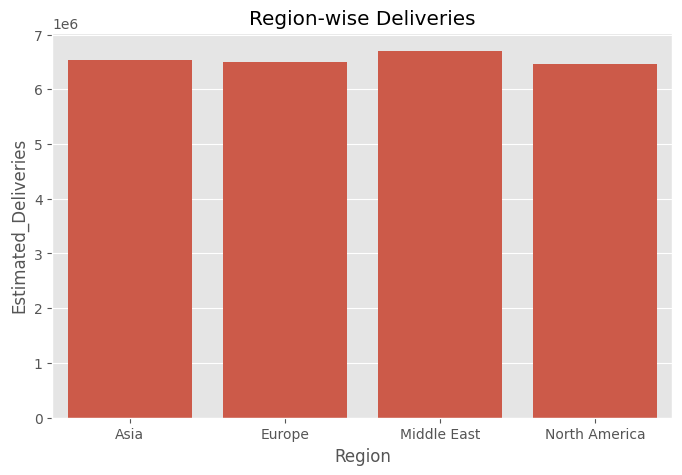

In [24]:
region_delivery=df.groupby("Region")["Estimated_Deliveries"].sum().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_delivery,
    x="Region",
    y="Estimated_Deliveries"
)

plt.title("Region-wise Deliveries")
plt.show()

Price vs Deliveries Analysis

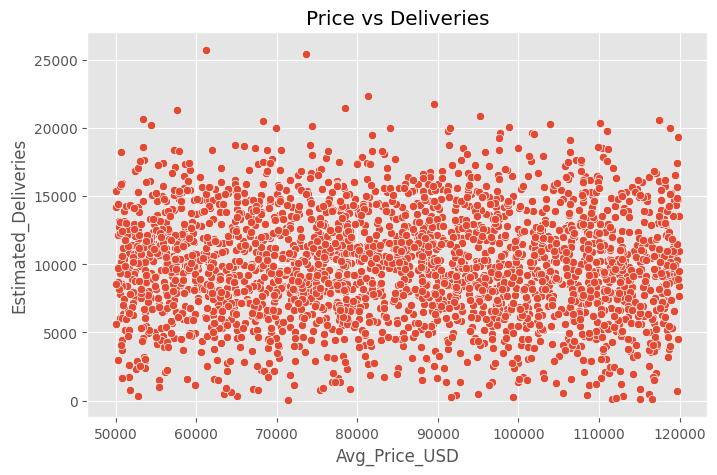

In [25]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Avg_Price_USD",
    y="Estimated_Deliveries"
)

plt.title("Price vs Deliveries")
plt.show()

Correlation Analysis

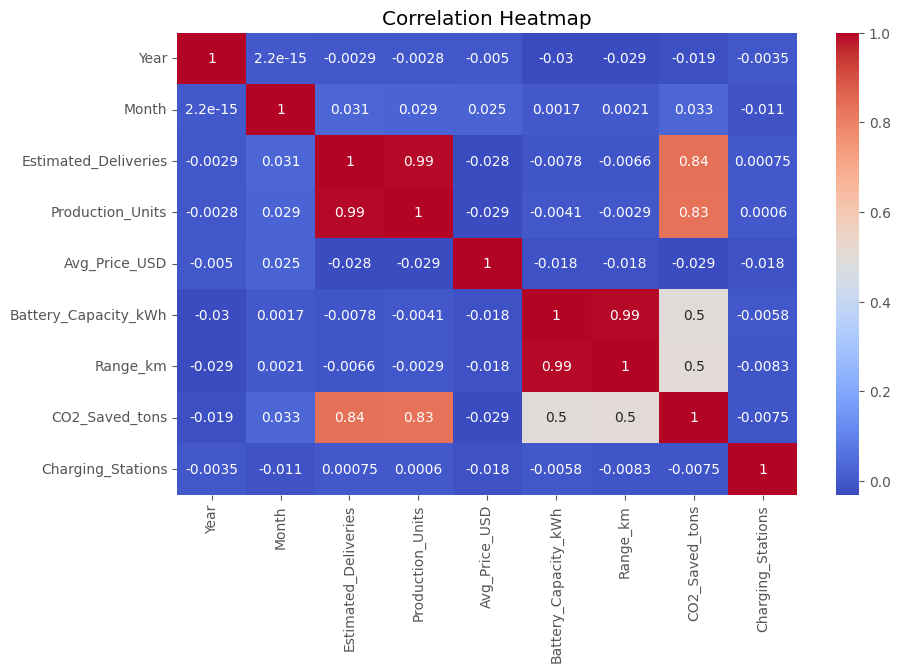

In [26]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Feature Engineering
Description

Creating new features that may improve machine learning model performance.

In [27]:
df["Delivery_Efficiency"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

In [28]:
df[["Estimated_Deliveries","Production_Units","Delivery_Efficiency"]].head()

,Estimated_Deliveries,Production_Units,Delivery_Efficiency
0,17646,17922,0.984600
1,3797,4164,0.911864
2,8411,9189,0.915334
3,6555,7311,0.896594
4,12374,13537,0.914087


In [29]:
df["Price_Per_KM"] = (
    df["Avg_Price_USD"] /
    df["Range_km"]
)

In [30]:
df["Production_Gap"] = (
    df["Production_Units"] -
    df["Estimated_Deliveries"]
)

In [31]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Delivery_Efficiency,Price_Per_KM,Production_Gap
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,0.984600,131.923679,276
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,0.911864,142.022032,367
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,0.915334,245.598583,778
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,0.896594,125.414199,756
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,0.914087,173.747020,1163


In [32]:
df.shape

(2640, 16)

Feature Selection

Selecting input features and target variable for machine learning.

In [33]:
y = df["Estimated_Deliveries"]

In [34]:
X = df.drop(
    ["Estimated_Deliveries","Date"],
    axis=1
)

Encoding Categorical Variables

In [35]:
X = pd.get_dummies(
    X,
    columns=["Region","Model","Source_Type"],
    drop_first=True
)

In [36]:
X.head()

,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Delivery_Efficiency,Price_Per_KM,Production_Gap,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17922,92874.27,120,704,1863.42,12207,0.984600,131.923679,276,True,False,False,False,True,False,False,True,False
1,2015,2,4164,62205.65,75,438,249.46,7640,0.911864,142.022032,367,False,False,False,False,False,True,False,False,True
2,2019,1,9189,117887.32,82,480,605.59,14071,0.915334,245.598583,778,False,False,True,False,False,True,False,True,False
3,2021,2,7311,89294.91,120,712,700.07,9333,0.896594,125.414199,756,False,False,True,True,False,False,False,False,True
4,2016,12,13537,114846.78,120,661,1226.88,8722,0.914087,173.747020,1163,False,True,False,False,False,False,True,False,False


Train-Test Split

The dataset is divided into training and testing sets. 
The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

Linear Regression Model

Linear Regression is used as a baseline model to predict Tesla deliveries based on the selected features.

In [40]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
y_pred_lr = lr.predict(X_test)

In [42]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

print("R2 Score:", r2_score(y_test, y_pred_lr))

MAE: 1.3651786771747124e-11
RMSE: 1.622675233968679e-11
R2 Score: 1.0


Random Forest Regression Model

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
y_pred_rf = rf.predict(X_test)

In [45]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 66.68958333333332
RMSE: 110.26376401061177
R2 Score: 0.9991843645081434


Model Comparison

In [46]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,1.000000
1,Random Forest,0.999184


Results

Random Forest achieved a higher R² score compared to Linear Regression, indicating better predictive performance on Tesla delivery data.

Feature Importance Analysis

In [47]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,Production_Units,0.989920
8,Delivery_Efficiency,0.007630
10,Production_Gap,0.001602
6,CO2_Saved_tons,0.000158
9,Price_Per_KM,0.000102
0,Year,0.000101
3,Avg_Price_USD,0.000095
7,Charging_Stations,0.000086
1,Month,0.000077
5,Range_km,0.000057


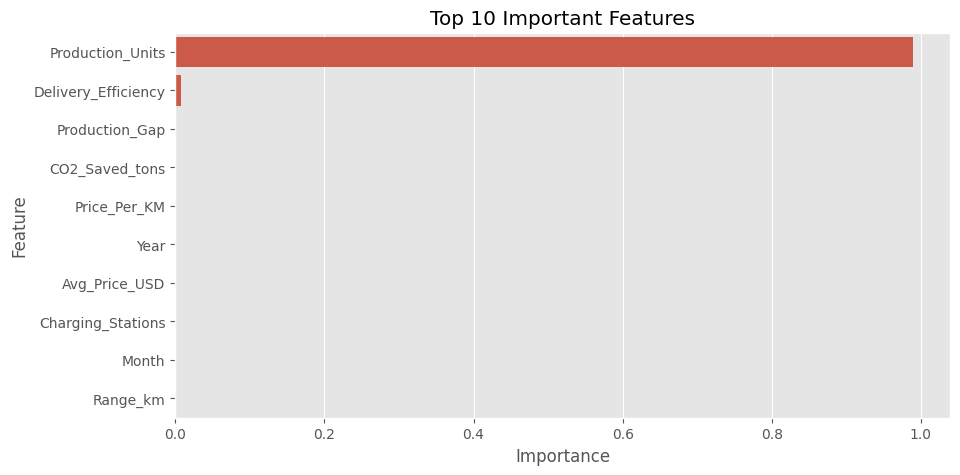

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

Hyperparameter Tuning

In [49]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [50]:
print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'n_estimators': 200}
0.9984899147839814


Time Series Forecasting

Historical delivery data is used to forecast future Tesla deliveries using Facebook Prophet.

In [51]:
ts = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

ts.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264


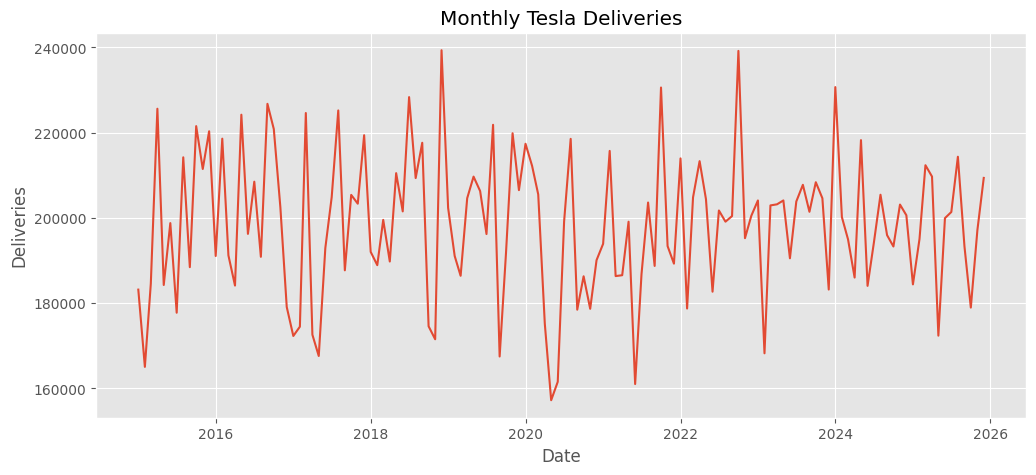

In [52]:
plt.figure(figsize=(12,5))

plt.plot(
    ts["Date"],
    ts["Estimated_Deliveries"]
)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [54]:
from prophet import Prophet

In [55]:
prophet_df = ts.rename(
    columns={
        "Date":"ds",
        "Estimated_Deliveries":"y"
    }
)

In [56]:
model = Prophet()

model.fit(prophet_df)

22:57:47 - cmdstanpy - INFO - Chain [1] start processing
22:57:49 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
future = model.make_future_dataframe(
    periods=12,
    freq="M"
)

forecast = model.predict(future)

D:\desktop-new\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Forecast Visualization

The forecasted delivery values are visualized to understand future trends and expected growth.

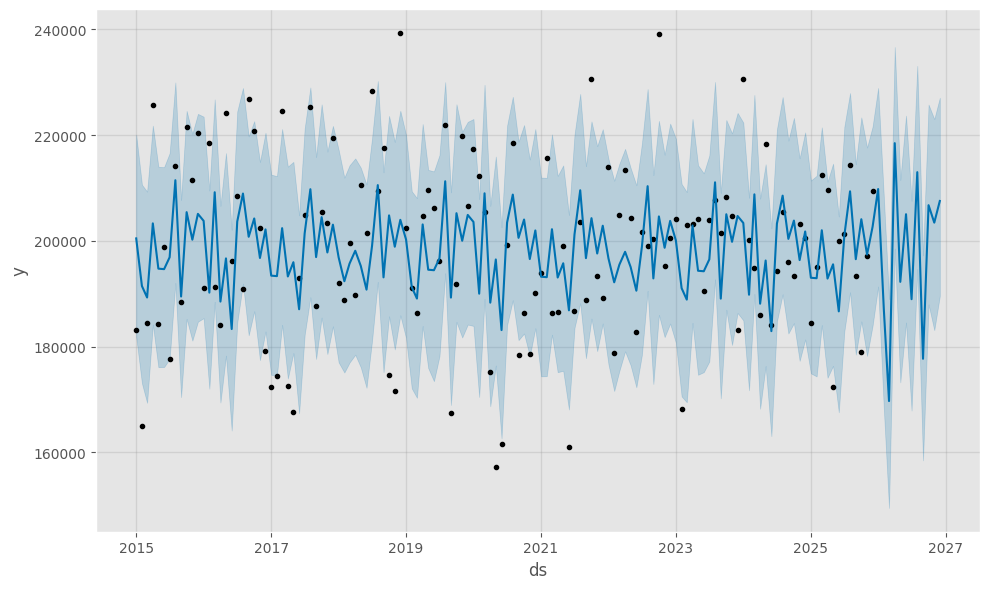

In [58]:
model.plot(forecast)

plt.show()

# Conclusion

This project successfully implemented an end-to-end machine learning pipeline on Tesla sales and production data.

Key achievements:
- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis.
- Created new engineered features.
- Built Linear Regression and Random Forest models.
- Compared model performance using regression metrics.
- Tuned hyperparameters using GridSearchCV.
- Forecasted future deliveries using Prophet.

The analysis indicates that machine learning techniques can effectively model Tesla delivery trends and provide insights into future growth.